# 03e — Pre-Flight Feature Engineering (Problem C)

Build the final feature matrix for the pre-flight risk model.

**Input:** `data/processed/preflight_weather_enriched.parquet`  
**Output:** `data/processed/preflight_features_final.parquet`

In [1]:
import os, sys
from pathlib import Path

root = Path.cwd()
while not (root / 'pyproject.toml').exists():
    root = root.parent
os.chdir(root)

# Ensure src/ is on the Python path for local imports
src_path = str(root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f'Working directory: {root}')
print(f'sys.path[0]: {sys.path[0]}')

Working directory: e:\OSFDA
sys.path[0]: e:\OSFDA\src


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from features.preflight import add_temporal_features, compute_historical_rates, categorize_weather

IN_PATH  = Path('data/processed/preflight_weather_enriched.parquet')
OUT_PATH = Path('data/processed/preflight_features_final.parquet')

df = pd.read_parquet(IN_PATH)
print(f'Loaded dataset: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Incident rate: {df["incident"].mean()*100:.2f}%')

Loaded dataset: (1012278, 31)
Columns: ['FL_DATE', 'OP_UNIQUE_CARRIER', 'OP_CARRIER_FL_NUM', 'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_ABR', 'DEST', 'DEST_CITY_NAME', 'DEST_STATE_ABR', 'DEP_TIME', 'DEP_DELAY', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'DIVERTED', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'airport_code', 'incident', 'departure_timestamp', 'weather_lookup_time', 'temp', 'dwpt', 'rhum', 'prcp', 'wspd', 'pres']
Incident rate: 4.76%


## 1. Temporal Features

In [3]:
df = add_temporal_features(df)

# Route ID for historical rate tracking
df['route_id'] = df['ORIGIN'].astype(str) + '_' + df['DEST'].astype(str)

print('Temporal features added:')
print(df[['month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'hour']].describe())

Temporal features added:
          month_sin     month_cos       dow_sin       dow_cos          hour
count  1.012278e+06  1.012278e+06  1.012278e+06  1.012278e+06  1.012278e+06
mean  -5.881796e-02 -6.621988e-02  1.724188e-02  4.418502e-03  1.276744e+01
std    7.134522e-01  6.950844e-01  6.946456e-01  7.191326e-01  5.323308e+00
min   -1.000000e+00 -1.000000e+00 -9.749279e-01 -9.009689e-01  0.000000e+00
25%   -8.660254e-01 -5.000000e-01 -7.818315e-01 -9.009689e-01  8.000000e+00
50%   -2.449294e-16 -1.836970e-16  0.000000e+00 -2.225209e-01  1.300000e+01
75%    8.660254e-01  5.000000e-01  7.818315e-01  6.234898e-01  1.700000e+01
max    1.000000e+00  1.000000e+00  9.749279e-01  1.000000e+00  2.400000e+01


## 2. Weather Features

In [4]:
df = categorize_weather(df)

# Impute missing weather with global medians
weather_cols = ['temp', 'dwpt', 'rhum', 'prcp', 'wspd', 'pres']
for col in weather_cols:
    if col in df.columns:
        med = df[col].median()
        n_missing = df[col].isna().sum()
        df[col] = df[col].fillna(med)
        if n_missing > 0:
            print(f'  Imputed {n_missing:,} missing {col} values with median={med:.2f}')
    else:
        df[col] = 0.0
        print(f'  WARNING: {col} not found, set to 0')

print('Weather features ready.')

  Imputed 274,106 missing temp values with median=17.80
  Imputed 274,178 missing dwpt values with median=10.60
  Imputed 274,178 missing rhum values with median=70.00
  Imputed 321,836 missing prcp values with median=0.00
  Imputed 274,714 missing wspd values with median=11.20
  Imputed 278,038 missing pres values with median=1016.20
Weather features ready.


## 3. Historical Incident Rates (Leakage-Free)

In [5]:
# compute_historical_rates uses expanding().mean().shift(1) — no data leakage
print('Computing historical incident rates...')

df['airport_risk_rate']  = compute_historical_rates(df, 'ORIGIN')
df['carrier_risk_rate']  = compute_historical_rates(df, 'OP_UNIQUE_CARRIER')
df['route_risk_rate']    = compute_historical_rates(df, 'route_id')

# Fill initial nulls (no prior history) with 0
for col in ['airport_risk_rate', 'carrier_risk_rate', 'route_risk_rate']:
    df[col] = df[col].fillna(0)

print('Historical rates computed:')
print(df[['airport_risk_rate', 'carrier_risk_rate', 'route_risk_rate']].describe())

Computing historical incident rates...
Historical rates computed:
       airport_risk_rate  carrier_risk_rate  route_risk_rate
count       1.012278e+06       1.012278e+06     1.012278e+06
mean        4.580796e-02       4.701266e-02     4.581967e-02
std         5.723943e-02       1.496191e-02     6.065279e-02
min         0.000000e+00       0.000000e+00     0.000000e+00
25%         0.000000e+00       3.807070e-02     0.000000e+00
50%         3.387534e-02       4.848372e-02     3.116147e-02
75%         7.642039e-02       5.514009e-02     7.594937e-02
max         1.000000e+00       1.000000e+00     1.000000e+00


## 4. Feature Correlation Analysis

Features available: ['month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'hour', 'temp', 'rhum', 'prcp', 'wspd', 'pres', 'airport_risk_rate', 'carrier_risk_rate', 'route_risk_rate', 'DISTANCE']


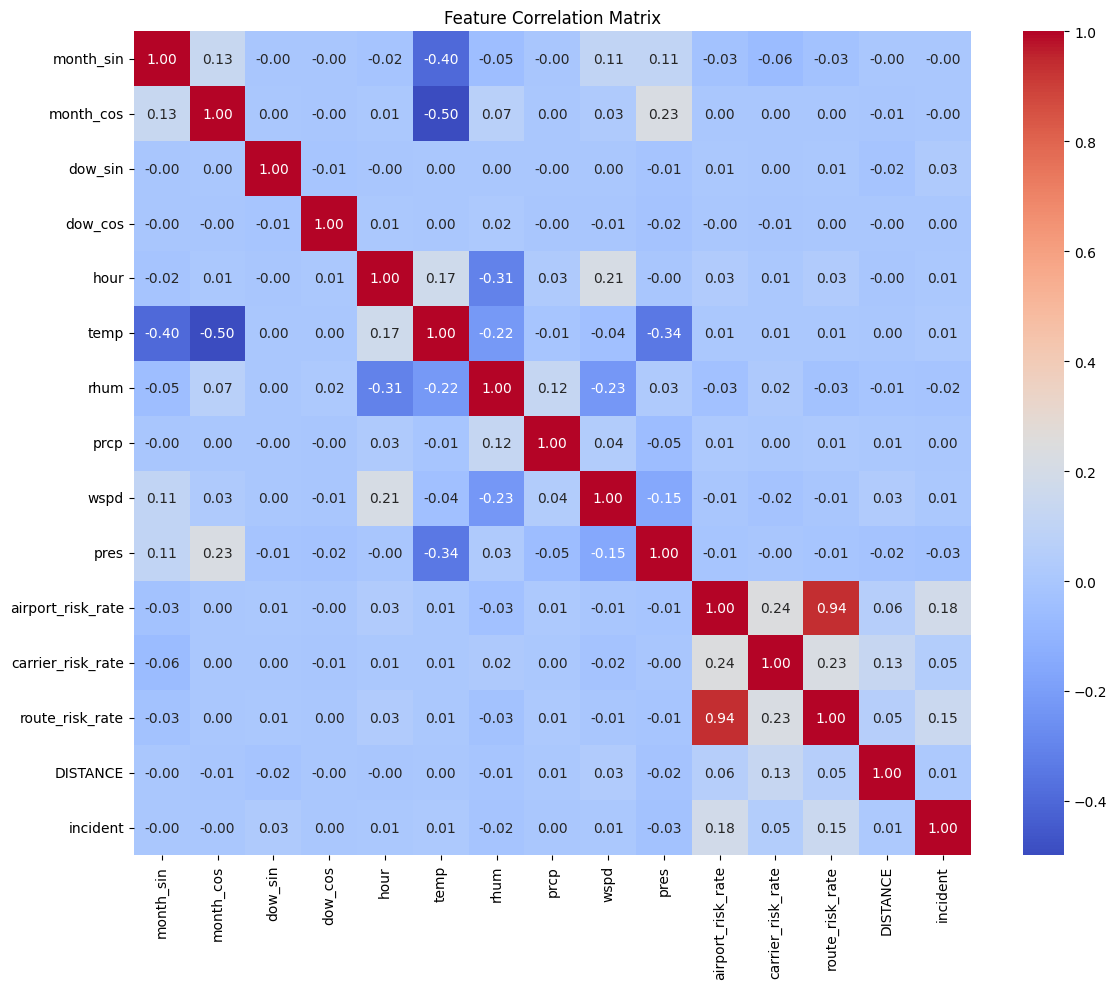

In [6]:
features = [
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'hour',
    'temp', 'rhum', 'prcp', 'wspd', 'pres',
    'airport_risk_rate', 'carrier_risk_rate', 'route_risk_rate',
    'DISTANCE'
]

# Only include features that exist in the DataFrame
available_features = [f for f in features if f in df.columns]
print(f'Features available: {available_features}')

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df[available_features + ['incident']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 5. Save

In [7]:
# Save the enriched feature matrix
df.to_parquet(OUT_PATH, index=False)
print(f'Saved final feature matrix to {OUT_PATH}')
print(f'Shape: {df.shape}')
print(f'Features saved: {available_features}')

Saved final feature matrix to data\processed\preflight_features_final.parquet
Shape: (1012278, 43)
Features saved: ['month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'hour', 'temp', 'rhum', 'prcp', 'wspd', 'pres', 'airport_risk_rate', 'carrier_risk_rate', 'route_risk_rate', 'DISTANCE']
